# Ensemble Methods in RAG 

We're going to build a retrieval system for *The Godfather* — then make it progressively smarter using ensemble techniques.

**The core idea:** instead of picking one retrieval strategy and hoping for the best, we let multiple retrievers vote — then train a model to learn *which votes to trust*.

![](https://imgur.com/Cr6SWDx.png)


In [ ]:
# Libraries
import numpy as np
import pandas as pd

#Baseline Retrievers
import bm25s
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

#Ensemble Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

#Utils
import time
import matplotlib.pyplot as plt
import os



# Data Source (The Godfather)
url: `https://www.kkoworld.com/kitablar/Mario_Puzo-The_Godfather_eng.pdf`

![](https://images.mubicdn.net/images/film/488/cache-47680-1745490954/image-w1280.jpg?size=800x)

## Data Preparation

### 1. Chunking Strategy & Cleaning
The overall Chunking Strategy and data cleaning is outside of the scope of this module. However, as a friendly reminder, it generally takes up a lot more time than model training!

I chose this data source for a few additional reasons, namely it required a lot of data cleaning! In brief I did the following:
- Detected page content borders and extracted content only from within those borders
- Detected hierarchical separation (3 levels) of content (Titles, Chapters, sub-chapters etc.) using regular expressions and font/format analysis
- Detected paragraphs within hierarchy using line spacing and positioning
- Created 1000+ chunks from 2500 paragpraphs by identifying mean paragraph size and normalising for paragraphs X% above (splitting) or below (joining)mean paragraph size within lowest hierarchy (Level 3)

### 2. Dataset labeling (Generating queries for each chunk)
In order for a more interesting and practical demonstration of ensemble methods, I used a small open-source LLM (Qwen3-4B-Instruct-2507) to generate entity-dense, fact-based queries for each chunk (that is only answerable from the text within that chunk)

![](https://imgur.com/JX4pIai.png)

In [3]:
pd.set_option('display.max_colwidth', None)
df_godfather = pd.read_csv("../datasets/godfather_chunks_prompts_all.csv")

df_godfather = df_godfather.drop(columns=['Unnamed: 0'], errors='ignore') 
df_godfather.tail(1)

,chunk_id,content,section_str,generated_query
1113,1112,"She emptied her mind of all thought of herself, of her children, of all anger, of all rebellion, of all questions. Then with a profound and deeply willed desire to believe, to be heard, as she had done every day since the murder of Carlo Rizzi, she said the necessary prayers for the soul of Michael Corleone.",9-1-2,"What prayers did she offer for Michael Corleone, and why, after the murder of Carlo Rizzi?"


In [21]:
# Unique chunks (one row per chunk_id)
chunks = (df_godfather[["chunk_id", "content", "section_str"]].drop_duplicates("chunk_id").sort_values("chunk_id").reset_index(drop=True))

## Model Selection

### Why Four Retrievers?

Each retriever sees the world differently. A query like *"who ordered the hit on Sonny?"* might be answered well by semantic search (understands meaning) but poorly by TF-IDF (looks for exact words).

![](https://imgur.com/aZO0Ca8.png?size=400x)




No single retriever wins every time. That's exactly why ensembles exist.

In [5]:
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME)

def embed_texts(texts, normalize=True, batch_size=64):
    emb = embedder.encode(
        list(map(str, texts)),
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
    ).astype(np.float32)
    return emb

# Chunk embeddings
E_chunks_cos = embed_texts(chunks["content"], normalize=True) 
E_chunks_raw = embed_texts(chunks["content"], normalize=False)  

### Lexical Retrieval

In [ ]:
def tf_idf_matrix(df, corpus_col):
    corpus = df[corpus_col].astype(str).tolist()
    vectorizer= TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
    matrix = vectorizer.fit_transform(corpus)
    return vectorizer, matrix

tfidf_vectorizer, tfidf_matrix = tf_idf_matrix(chunks, "content")

def build_bm25(df, corpus_col):
    corpus = df[corpus_col].astype(str).tolist()
    corpus_tokens = bm25s.tokenize(corpus, stopwords='english')
    bm25_algo = bm25s.BM25()
    bm25_algo.index(corpus_tokens)
    return bm25_algo

bm25_retriever = build_bm25(chunks, "content")

Split strings:   0%|          | 0/1112 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/1112 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/1112 [00:00<?, ?it/s]

### Query-to-Chunk Search

In [7]:
def topk_idx(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, len(scores))
    idx = np.argpartition(-scores, k-1)[:k]
    return idx[np.argsort(-scores[idx])]

In [ ]:
def retrieve_chunk_cos(query: str, k: int = 10):
    q = embed_texts([query], normalize=True)[0]
    scores = E_chunks_cos @ q
    idx = topk_idx(scores, k)
    return idx, scores[idx], scores

def retrieve_chunk_dot(query: str, k: int = 10):
    q = embed_texts([query], normalize=False)[0]
    scores = E_chunks_raw @ q
    idx = topk_idx(scores, k)
    return idx, scores[idx], scores

def retrieve_tfidf(query: str, k: int = 10):
    q = tfidf_vectorizer.transform([query])
    scores = (tfidf_matrix @ q.T).toarray().ravel()
    idx = topk_idx(scores, k)
    return idx, scores[idx]

def retrieve_bm25(query: str, k: int = 10):
    q = str(query).lower().split()
    scores = bm25_retriever.get_scores(q)
    idx = topk_idx(scores, k)
    return idx, scores[idx]

## Evaluation

### What Are We Measuring?

| Metric | Question it answers |
|--------|-------------------|
| **Recall@1** | Was the right chunk the very top result? |
| **Recall@5** | Was the right chunk anywhere in the top 5? |
| **MRR** | On average, how high did the right chunk rank? |
| **Time p95** | How slow are the worst 5% of queries? |

💡 **Why MRR over accuracy?** Ranking 2nd is much better than ranking 20th — accuracy doesn't capture that. MRR rewards systems that consistently put the right answer near the top.

In [9]:
def recall_at_k(ranked_chunk_ids, true_chunk_id, k: int) -> float:
    return 1.0 if int(true_chunk_id) in list(map(int, ranked_chunk_ids[:k])) else 0.0

def mrr(ranked_chunk_ids, true_chunk_id) -> float:
    true_chunk_id = int(true_chunk_id)
    for i, cid in enumerate(map(int, ranked_chunk_ids), start=1):
        if cid == true_chunk_id:
            return 1.0 / i
    return 0.0

def time_call(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    end = time.perf_counter()
    latency_ms = (end - start) * 1000.0
    return result, latency_ms

In [ ]:
def eval_retriever(df_eval: pd.DataFrame, retriever_fn, k: int = 10):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df_eval.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        (idx, *_), latency_ms = time_call(retriever_fn, q, k=k)
        latencies.append(latency_ms)

        ranked_ids = chunks.iloc[idx]["chunk_id"].tolist()

        rec1.append(recall_at_k(ranked_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_ids, true_id, 5))
        rr.append(mrr(ranked_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2), # Latency in ms
    }

In [11]:
def rank_of(order: np.ndarray, idx: int) -> int:
    pos = np.where(order == idx)[0]
    return int(pos[0] + 1) if len(pos) else 10**9

## Training Dataset

**Score Query<-->Chunk pairs:** 
For every query, each retriever independently nominates its top-k chunk candidates — returning not just the chunk IDs, but their scores and ranks. The candidate pool is then the union of those shortlists, typically a fraction of the total corpus.

In [ ]:
def score_query_chunk_pairs(query: str, k_each: int = 15):
    # Retrieve Chunks using each Baseline model
    idx_cos, _, all_cos   = retrieve_chunk_cos(query, k=k_each)
    idx_dot, _, all_dot   = retrieve_chunk_dot(query, k=k_each)
    idx_tfidf, _ = retrieve_tfidf(query, k=k_each)
    idx_bm25, _ = retrieve_bm25(query, k=k_each)

    # Create a unique set of retrieved chunks
    candidates = sorted(set(idx_cos.tolist()) | set(idx_dot.tolist()) | set(idx_tfidf.tolist()) | set(idx_bm25.tolist()))

    # Generate query scores for Lexicals
    qv = tfidf_vectorizer.transform([query])
    all_tfidf = (tfidf_matrix @ qv.T).toarray().ravel()
    q_bm25 = str(query).lower().split()
    all_bm25 = bm25_retriever.get_scores(q_bm25)

    rows = []
    for r in candidates:
        r = int(r)
        chunk_id = int(chunks.iloc[r]["chunk_id"])

        rows.append({
            "chunk_id": chunk_id,

            # Features: raw scores
            "cos_chunk": float(all_cos[r]),
            "dot_chunk": float(all_dot[r]),
            "tfidf_chunk": float(all_tfidf[r]),
            "bm25_chunk": float(all_bm25[r]),

            # Features: rankings --> use rankings to avoid normalising raw scores
            "rank_cos": rank_of(idx_cos, r),
            "rank_dot": rank_of(idx_dot, r),
            "rank_tfidf": rank_of(idx_tfidf, r),
            "rank_bm25": rank_of(idx_bm25, r),

        })

    return pd.DataFrame(rows)

For each row, there is a unique `chunk_id`, `query` pair, with additional labels:
- Source of truth: `query_id`, `query`, `true_chunk_id`: which query this chunk SHOULD be matched to
- Binary label: `y_label` 1 if correct, else 0
- Retriever Scores and Rankings: for this chunk<-->query pair i.e. `cos_chunk, dot_chunk, tfidf_chunk, bm25_chunk, rank_cos, rank_dot, rank_tfidf, rank_bm25`

These Scores and Rankings are possible features to be used when training the Logistic Regression (Stacking) and GBDT (Boosting) models.

In [25]:
def label_query_chunk_pairs(df: pd.DataFrame, k_each: int = 15):
    rows = []
    for _, r in df.reset_index(drop=True).iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        feats = score_query_chunk_pairs(q, k_each=k_each)
        feats["query_id"] = true_id
        feats["query"] = q
        feats["true_chunk_id"] = true_id
        feats["y_label"] = (feats["chunk_id"] == true_id).astype("int32")
        rows.append(feats)

    return pd.concat(rows, ignore_index=True)

training_dataset = label_query_chunk_pairs(df_godfather, k_each=20)

### Train, test, split

In [ ]:
feature_cols = ["rank_cos", "rank_dot", "rank_tfidf","rank_bm25"]

X = training_dataset[feature_cols].astype(np.float32).values
y = training_dataset["y_label"].astype(int).values

# Note: do not separate candidate chunks with the same query_id
unique_q = training_dataset["query_id"].unique()
q_train, q_test = train_test_split(unique_q, test_size=0.2, random_state=42)

# Boolean masks — True for rows belonging to train/test queries respectively
train_mask = training_dataset["query_id"].isin(q_train).values
test_mask = training_dataset["query_id"].isin(q_test).values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

df_test = df_godfather.reset_index(drop=True).iloc[q_test].reset_index(drop=True)

### Baseline Results (Individual Retrievers)

- **Lexical** (TF-IDF, BM25) is fast (sub-millisecond) but misses semantic meaning
- **Semantic** (cos, dot) handles paraphrasing well but is slower and can miss keyword-heavy queries
- No single retriever dominates on all metrics

This is the *motivation* for examining ensemble methods.

In [14]:
baseline_results = pd.DataFrame([
    {"retriever": "embed_cos", **eval_retriever(df_test, retrieve_chunk_cos, k=10)},
    {"retriever": "embed_dot", **eval_retriever(df_test, retrieve_chunk_dot, k=10)},
    {"retriever": "lex_tfidf", **eval_retriever(df_test, retrieve_tfidf, k=10)},
    {"retriever": "lex_bm25",  **eval_retriever(df_test, retrieve_bm25, k=10)},
])

baseline_results

,retriever,Recall@1,Recall@5,MRR,Time_p95
0,embed_cos,0.57,0.79,0.66,6.51
1,embed_dot,0.57,0.79,0.66,6.08
2,lex_tfidf,0.67,0.83,0.74,0.28
3,lex_bm25,0.66,0.79,0.72,0.04


## 🥞 Stacking — Training a LogReg model to re-rank query-chunk candidates across all retrievers

Stacking asks: *"Given that each retriever has already had its say, can we learn which signals to trust?"*
![](https://imgur.com/DxXBXkz.png?size=100x)

### Why ranks rather than raw scores?

Raw scores are not comparable across retrievers — a BM25 score of 4.2 and a cosine similarity of 0.87 live on completely different scales. 

Tip: converting to ranks normalises all scores without having to introduce Standard Scaler (and is more intuitive)!

### The Training Setup

Each training example is a `(query, candidate_chunk)` pair. The label is `1` if that chunk is the true answer, `0` otherwise. With ~20 candidates per query and only 1 correct answer, the dataset is heavily imbalanced — hence `class_weight="balanced"` in the LogisticRegression.


In [22]:
stacking_method = LogisticRegression(max_iter=2000, class_weight="balanced")
stacking_method.fit(X_train, y_train)

def stacking_ensemble(df, k_each: int = 20):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        start = time.perf_counter()

        feats = build_candidate_features(q, k_each=k_each)
        Xq = feats[feature_cols].astype(np.float32).values
        p = stacking_method.predict_proba(Xq)[:, 1]

        order = np.argsort(-p)
        ranked_chunk_ids = feats.iloc[order]["chunk_id"].tolist()

        end = time.perf_counter()
        latencies.append((end - start) * 1000.0)

        rec1.append(recall_at_k(ranked_chunk_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_chunk_ids, true_id, 5))
        rr.append(mrr(ranked_chunk_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2),
    }

stacking_results = stacking_ensemble(df_test, k_each=20)

## 🚀 Boosting — Learning From Mistakes

Stacking trains a logistic regression on the full feature set. Boosting goes further — it trains an *ensemble of trees sequentially*, each one focusing on the examples the previous trees got wrong.

![](https://imgur.com/RCtVCoG.png)

In [16]:
boosting_method = GradientBoostingClassifier(random_state=42)
boosting_method.fit(X_train, y_train)


def boosting_ensemble(df, k_each: int = 20):
    rec1 = []
    rec5 = []
    rr = []
    latencies = []

    for _, r in df.iterrows():
        q = r["generated_query"]
        true_id = int(r["chunk_id"])

        start = time.perf_counter()

        feats = build_candidate_features(q, k_each=k_each)
        Xq = feats[feature_cols].astype(np.float32).values
        p = boosting_method.predict_proba(Xq)[:, 1]

        order = np.argsort(-p)
        ranked_chunk_ids = feats.iloc[order]["chunk_id"].tolist()

        end = time.perf_counter()
        latencies.append((end - start) * 1000.0)

        rec1.append(recall_at_k(ranked_chunk_ids, true_id, 1))
        rec5.append(recall_at_k(ranked_chunk_ids, true_id, 5))
        rr.append(mrr(ranked_chunk_ids, true_id))

    return {
        "Recall@1": round(float(np.mean(rec1)), 2),
        "Recall@5": round(float(np.mean(rec5)), 2),
        "MRR": round(float(np.mean(rr)), 2),
        "Time_p95": round(float(np.percentile(latencies, 95)), 2),
    }

boosting_results = boosting_ensemble(df_test, k_each=20)


## Results

In [17]:
rows = []

if "baseline_results" in globals():
    for _, r in baseline_results.iterrows():
        rows.append({
            "retriever": r["retriever"],
            "Recall@1": r["Recall@1"],
            "Recall@5": r["Recall@5"],
            "MRR": r["MRR"],
            "Time_p95": r["Time_p95"],
        })

if "stacking_results" in globals():
    rows.append({
        "retriever": "stacking_logr",
        "Recall@1": stacking_results["Recall@1"],
        "Recall@5": stacking_results["Recall@5"],
        "MRR": stacking_results["MRR"],
        "Time_p95": stacking_results["Time_p95"],
    })

if "boosting_results" in globals():
    rows.append({
        "retriever": "boosting_gbdt",
        "Recall@1": boosting_results["Recall@1"],
        "Recall@5": boosting_results["Recall@5"],
        "MRR": boosting_results["MRR"],
        "Time_p95": boosting_results["Time_p95"],
    })


results_df = pd.DataFrame(rows).drop_duplicates("retriever").reset_index(drop=True)
results_df


,retriever,Recall@1,Recall@5,MRR,Time_p95
0,embed_cos,0.57,0.79,0.66,6.51
1,embed_dot,0.57,0.79,0.66,6.08
2,lex_tfidf,0.67,0.83,0.74,0.28
3,lex_bm25,0.66,0.79,0.72,0.04
4,stacking_logr,0.69,0.88,0.77,15.32
5,boosting_gbdt,0.77,0.91,0.84,14.87


## 📊 Interpretation
**Baselines**
Lexical retrievers (TF-IDF: 0.67, BM25: 0.66) outperform semantic on Recall@1 — suggesting The Godfather corpus rewards keyword matching over semantic similarity, likely because queries are fairly literal against the source text.

**Ensembles**
Both ensembles beat every baseline, which is the result you expect. Boosting in particular is strong — Recall@1 of 0.77 is a +10 point lift over the best baseline, and Recall@5 of 0.91 means the right chunk is in the top 5 nine times out of ten.
**Stacking vs Boosting**
Boosting wins convincingly on every accuracy metric. With 1,000 chunks the feature relationships are likely non-linear enough that Logistic Regression can't fully capture them — GBDT's ability to model non-linear interactions between retriever ranks is more apparent.

**Latency**
Both ensembles sit around 15ms p95 — roughly 50x slower than TF-IDF. Depending on the use case, the accuracy gains may justify the latency. 

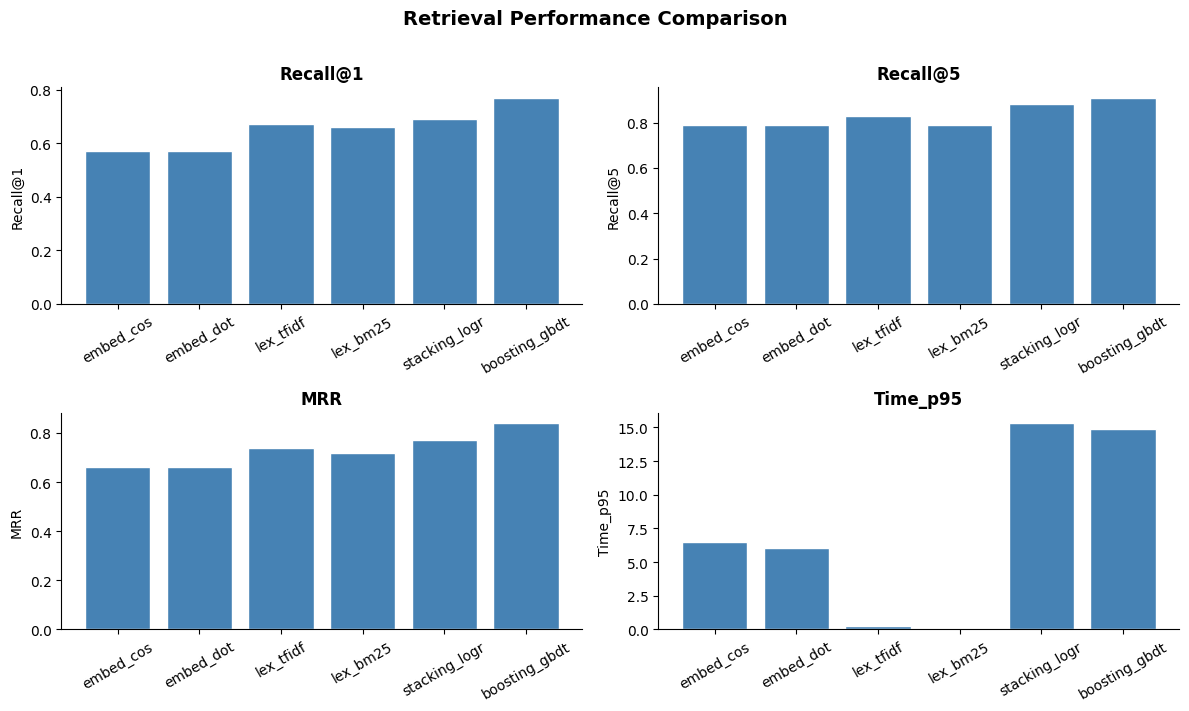

In [20]:
if len(results_df) == 0:
    raise ValueError("results_df is empty. Make sure you ran the earlier evaluation cells.")

metrics = ["Recall@1", "Recall@5", "MRR", "Time_p95"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Retrieval Performance Comparison", fontsize=14, fontweight="bold", y=1.01)

for ax, metric in zip(axes.flat, metrics):
    ax.bar(results_df["retriever"], results_df[metric], color="steelblue", edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()